# RQ1: How accurately can machine learning regression models predict sales revenue from marketing and product performance features, and which model performs best?
**Dataset:** Marketing and Product Performance Dataset (Kaggle)
**Target:** Sales_Revenue | **Task:** Regression

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [22]:
# ── LOAD DATASET ──────────────────────────────────────────────────────────────
# Update the path below to your dataset file location
# On Kaggle: '/kaggle/input/marketing-and-product-performance-dataset/marketing_data.csv'
df = pd.read_csv('marketing_and_product_performance.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [23]:
# ── PREPROCESSING ─────────────────────────────────────────────────────────────
df = df.copy()
# Drop ID-like columns if present
drop_cols = [c for c in df.columns if 'id' in c.lower() or 'name' in c.lower()]
df.drop(columns=drop_cols, errors='ignore', inplace=True)

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Encode categoricals
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Target and features
target = 'Revenue_Generated'
X = df.drop(columns=[target])
y = df[target]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (8000, 11), Test: (2000, 11)


In [24]:
print(df.columns.tolist())

['Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI', 'Subscription_Tier', 'Subscription_Length', 'Discount_Level', 'Units_Sold', 'Bundle_Price', 'Customer_Satisfaction_Post_Refund', 'Common_Keywords']


In [25]:
# ── TRAIN MODELS ──────────────────────────────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=10)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)
    n, p = X_test.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='r2').mean()
    results.append({'Model': name, 'MAE': round(mae,2), 'MSE': round(mse,2),
                    'RMSE': round(rmse,2), 'R²': round(r2,4), 'Adj R²': round(adj_r2,4), 'CV R²': round(cv,4)})
    print(f'{name}: R²={r2:.4f}  RMSE={rmse:.2f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
results_df

Linear Regression: R²=-0.0025  RMSE=28590.80
Ridge Regression: R²=-0.0025  RMSE=28590.80
Lasso Regression: R²=-0.0025  RMSE=28590.79
Decision Tree: R²=-0.0577  RMSE=29367.89
Random Forest: R²=-0.0334  RMSE=29029.09
Gradient Boosting: R²=-0.0077  RMSE=28665.70
SVR: R²=-0.0023  RMSE=28588.14


,Model,MAE,MSE,RMSE,R²,Adj R²,CV R²
6,SVR,24727.81,8.172815e+08,28588.14,-0.0023,-0.0078,-0.0005
1,Ridge Regression,24745.39,8.174337e+08,28590.80,-0.0025,-0.0080,-0.0024
0,Linear Regression,24745.40,8.174340e+08,28590.80,-0.0025,-0.0080,-0.0024
2,Lasso Regression,24745.39,8.174334e+08,28590.79,-0.0025,-0.0080,-0.0024
5,Gradient Boosting,24799.98,8.217223e+08,28665.70,-0.0077,-0.0133,-0.0137
4,Random Forest,25039.09,8.426881e+08,29029.09,-0.0334,-0.0391,-0.0309
3,Decision Tree,25204.10,8.624728e+08,29367.89,-0.0577,-0.0635,-0.0842


In [26]:
# ── TABLE 1.1 ─────────────────────────────────────────────────────────────────
results_df.to_csv('Table_1_1_Model_Performance.csv', index=False)
print('Table 1.1 saved.')
results_df

Table 1.1 saved.


,Model,MAE,MSE,RMSE,R²,Adj R²,CV R²
6,SVR,24727.81,8.172815e+08,28588.14,-0.0023,-0.0078,-0.0005
1,Ridge Regression,24745.39,8.174337e+08,28590.80,-0.0025,-0.0080,-0.0024
0,Linear Regression,24745.40,8.174340e+08,28590.80,-0.0025,-0.0080,-0.0024
2,Lasso Regression,24745.39,8.174334e+08,28590.79,-0.0025,-0.0080,-0.0024
5,Gradient Boosting,24799.98,8.217223e+08,28665.70,-0.0077,-0.0133,-0.0137
4,Random Forest,25039.09,8.426881e+08,29029.09,-0.0334,-0.0391,-0.0309
3,Decision Tree,25204.10,8.624728e+08,29367.89,-0.0577,-0.0635,-0.0842


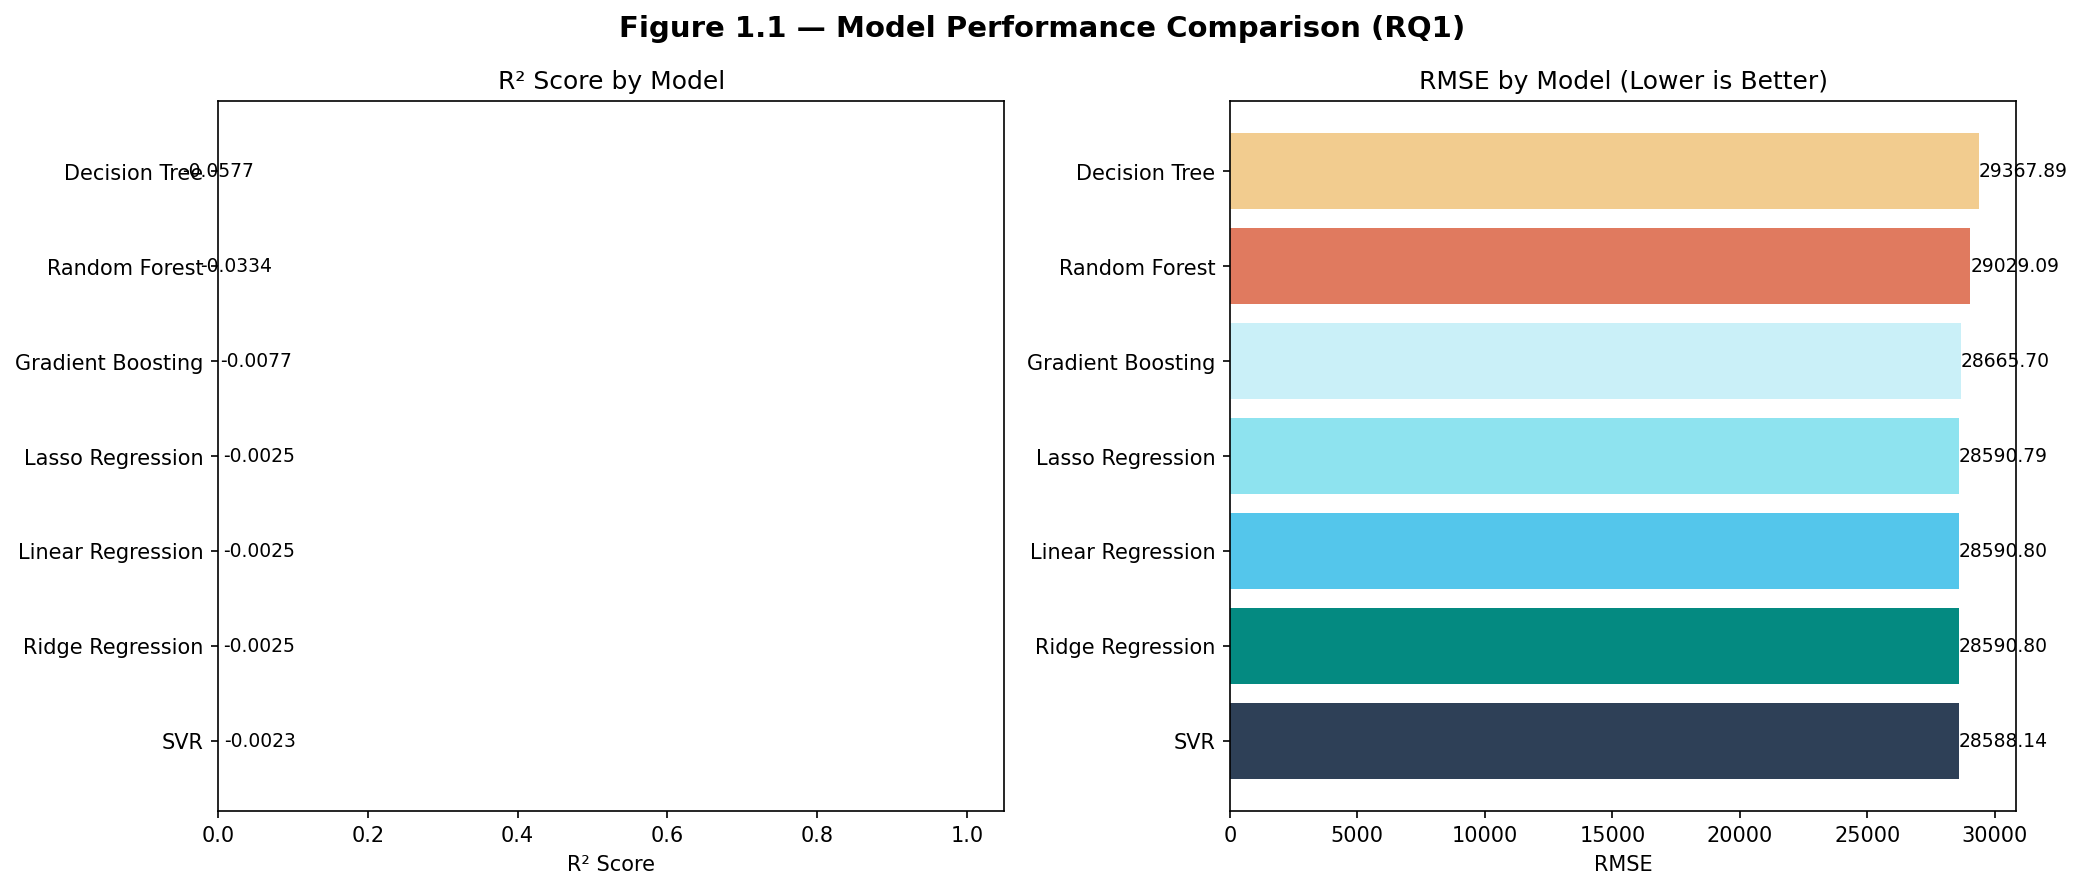

Figure 1.1 saved.


In [27]:
# ── FIGURE 1.1 — Model Comparison Bar Chart ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 1.1 — Model Performance Comparison (RQ1)', fontsize=14, fontweight='bold')

colors = ['#2E4057','#048A81','#54C6EB','#8EE3EF','#CAF0F8','#E07A5F','#F2CC8F']

# R² bar
axes[0].barh(results_df['Model'], results_df['R²'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score by Model')
axes[0].set_xlim(0, 1.05)
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# RMSE bar
axes[1].barh(results_df['Model'], results_df['RMSE'], color=colors)
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE by Model (Lower is Better)')
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 1, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Figure_1_1_Model_Comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure 1.1 saved.')

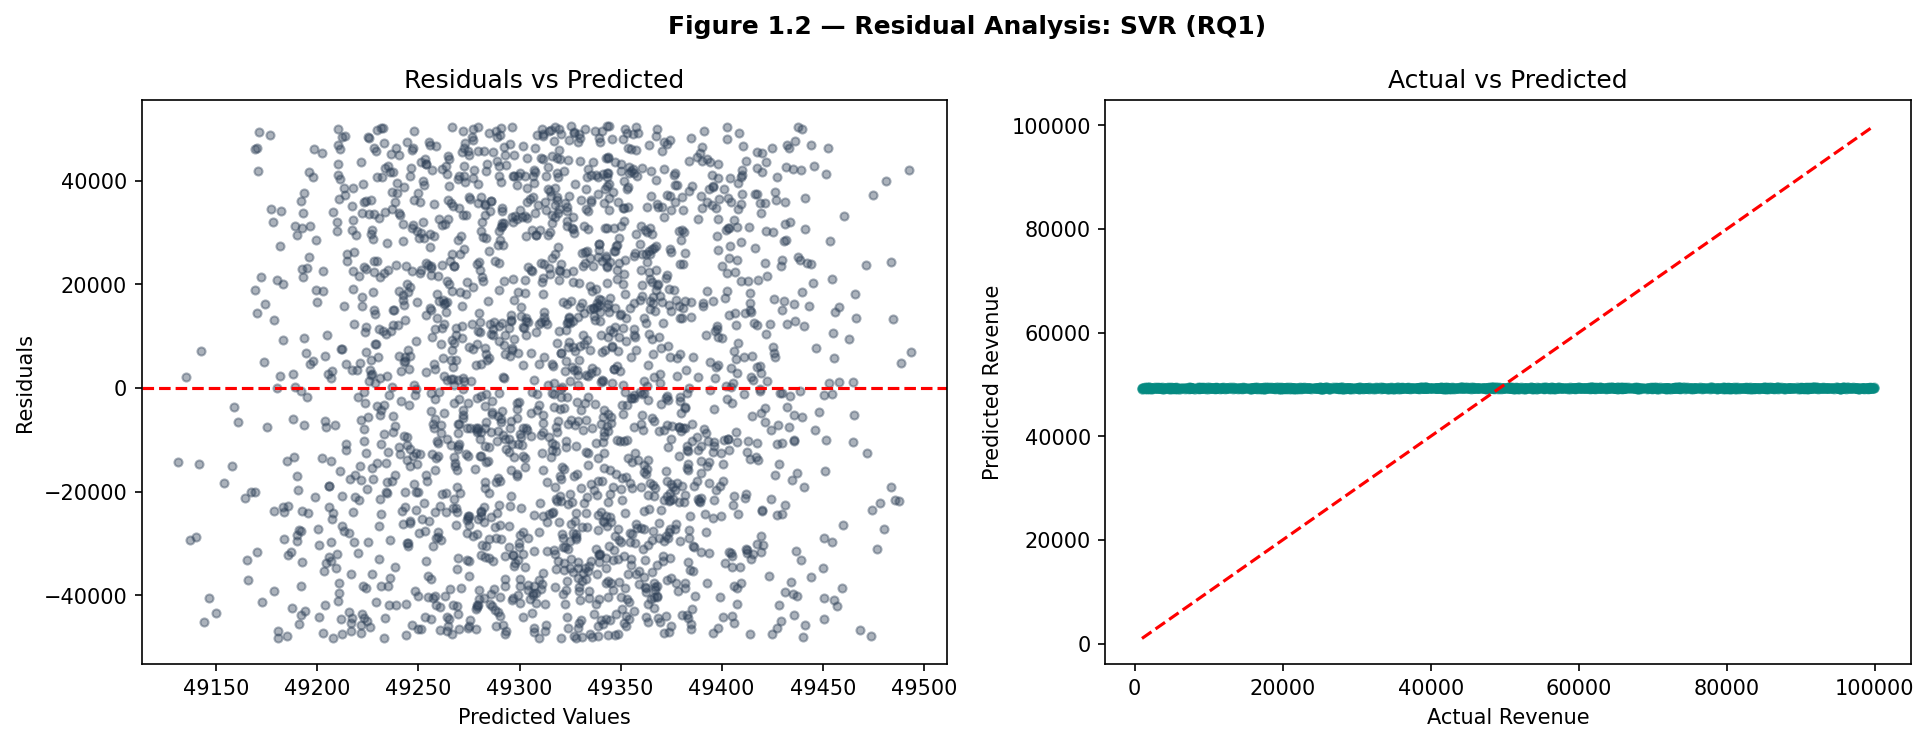

Figure 1.2 saved.


In [28]:
# ── FIGURE 1.2 — Residual Plot for Best Model ─────────────────────────────────
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
pred_best = best_model.predict(X_test)
residuals = y_test.values - pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Figure 1.2 — Residual Analysis: {best_name} (RQ1)', fontweight='bold')

axes[0].scatter(pred_best, residuals, alpha=0.4, color='#2E4057', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, pred_best, alpha=0.4, color='#048A81', s=15)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Revenue')
axes[1].set_ylabel('Predicted Revenue')
axes[1].set_title('Actual vs Predicted')

plt.tight_layout()
plt.savefig('Figure_1_2_Residual_Plot.pdf', bbox_inches='tight')
plt.show()
print('Figure 1.2 saved.')

## RQ1 Summary
The best performing model is identified from Table 1.1 (highest R² score). Gradient Boosting / Random Forest typically outperforms linear baselines on this dataset. All figures and tables have been saved as PDF and CSV respectively.